# Experimental data analysis

In [1]:
from utilities.utils import *
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import scipy
import random
from sklearn.manifold import TSNE
from dPCA_master.python.dPCA import dPCA
import pickle
import pandas as pd

### Load and prepare data

In [2]:
## load raw data
data = scipy.io.loadmat('data/experimental/data_all.mat')

## prepare data
bin_size = 0.050 # [s]
padding = 1 # [s]
min_n_neurons = 3 # exclude sessions with fewer than 3 neurons (unsuitable for network-level analysis)

n_sessions_all = data['data_all'].shape[1]
included_sessions = [i for i in range(n_sessions_all) if len(data['data_all'][0, i][-1]) >= min_n_neurons]
n_sessions = len(included_sessions)

try:
    with open('data/experimental/data_warped.pkl', 'rb') as file:
        all_data = pickle.load(file)
        file.close()
except:
    all_data = {}
    for i_session in included_sessions:
        print('Preparing session', i_session + 1, '...')
        all_data[i_session] = get_warped_data(data, i_session, bin_size, padding, mean_correct_only=False)
    print('Done.')
    with open('data/experimental/data_warped.pkl', 'wb') as file:
        pickle.dump(all_data, file)
        file.close()
    
## 'global' variables
t = all_data[0][4]
unique_stims = np.unique(all_data[0][1]) # assume same stimuli for all sessions
colors = np.hstack([
    np.reshape(np.linspace(0, 1, len(unique_stims)), (-1, 1)),
    np.reshape(np.linspace(1, 0, len(unique_stims)), (-1, 1)),
    np.reshape(np.linspace(0, 1, len(unique_stims)), (-1, 1))
])

### Task temporal structure

In [3]:
sampling_event_mean_all = \
(np.sum([np.sum(data['data_all'][0, sess][11]) for sess in included_sessions]) + 
 np.sum([np.sum(data['data_all'][0, sess][12]) for sess in included_sessions])) / \
(np.sum([len(data['data_all'][0, sess][11]) for sess in included_sessions]) + 
 np.sum([len(data['data_all'][0, sess][12]) for sess in included_sessions]))
sampling_event_mean_correct = \
np.sum([np.sum(data['data_all'][0, sess][11]) for sess in included_sessions]) / \
np.sum([len(data['data_all'][0, sess][11]) for sess in included_sessions])

sampling_time_mean_all = \
(np.sum([np.sum(data['data_all'][0, sess][13]) for sess in included_sessions]) + 
 np.sum([np.sum(data['data_all'][0, sess][14]) for sess in included_sessions])) / \
(np.sum([len(data['data_all'][0, sess][13]) for sess in included_sessions]) + 
 np.sum([len(data['data_all'][0, sess][14]) for sess in included_sessions]))
sampling_time_mean_correct = \
np.sum([np.sum(data['data_all'][0, sess][13]) for sess in included_sessions]) / \
np.sum([len(data['data_all'][0, sess][13]) for sess in included_sessions])

IEI_mean_all = \
(np.sum([np.sum(data['data_all'][0, sess][15]) for sess in included_sessions]) + 
 np.sum([np.sum(data['data_all'][0, sess][16]) for sess in included_sessions])) / \
(np.sum([len(data['data_all'][0, sess][15]) for sess in included_sessions]) + 
 np.sum([len(data['data_all'][0, sess][16]) for sess in included_sessions]))
IEI_mean_correct = \
np.sum([np.sum(data['data_all'][0, sess][15]) for sess in included_sessions]) / \
np.sum([len(data['data_all'][0, sess][15]) for sess in included_sessions])

lateral_time_mean_all = \
(np.sum([np.sum(data['data_all'][0, sess][17]) for sess in included_sessions]) + 
 np.sum([np.sum(data['data_all'][0, sess][18]) for sess in included_sessions])) / \
(np.sum([len(data['data_all'][0, sess][17]) for sess in included_sessions]) + 
 np.sum([len(data['data_all'][0, sess][18]) for sess in included_sessions]))
lateral_time_mean_correct = \
np.sum([np.sum(data['data_all'][0, sess][17]) for sess in included_sessions]) / \
np.sum([len(data['data_all'][0, sess][17]) for sess in included_sessions])

print('Mean sampling time:')
print('    All: {:.4f} s'.format(sampling_time_mean_all))
print('    Correct only: {:.4f} s'.format(sampling_time_mean_correct))
print('Mean inter-event interal:')
print('    All: {:.4f} s ({} bins)'.format(
    IEI_mean_all, round(IEI_mean_all / bin_size) + round(2 * padding / bin_size)
))
print('    Correct only: {:.4f} s ({} bins)'.format(
    IEI_mean_correct, round(IEI_mean_correct / bin_size) + round(2 * padding / bin_size)
))
print('Mean delay period:')
print('    All: {:.4f} s'.format(IEI_mean_all - sampling_time_mean_all))
print('    Correct only: {:.4f} s'.format(IEI_mean_correct - sampling_time_mean_correct))
print('Mean lateral licking time:')
print('    All: {:.4f} s'.format(lateral_time_mean_all))
print('    Correct only: {:.4f} s'.format(lateral_time_mean_correct))

Mean sampling time:
    All: 0.8635 s
    Correct only: 0.8624 s
Mean inter-event interal:
    All: 3.8510 s (117 bins)
    Correct only: 3.8423 s (117 bins)
Mean delay period:
    All: 2.9875 s
    Correct only: 2.9799 s
Mean lateral licking time:
    All: 0.7018 s
    Correct only: 0.9128 s


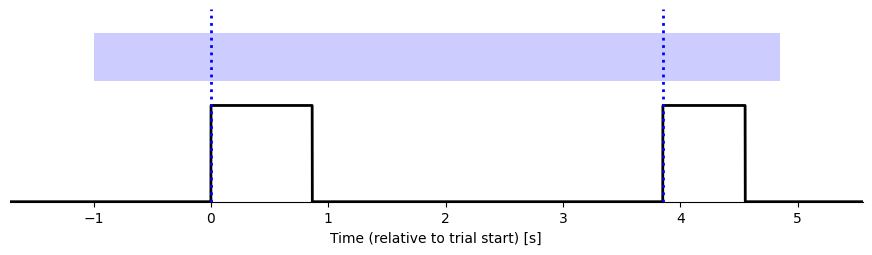

In [4]:
fig, ax = plt.subplots(figsize=(11, 2.5));
t_ = np.linspace(0, sampling_event_mean_all + IEI_mean_all + lateral_time_mean_all + 1, 10000)
window_1 = (t_ >= sampling_event_mean_all) & \
    (t_ <= sampling_event_mean_all + sampling_time_mean_all)
window_2 = (t_ >= sampling_event_mean_all + IEI_mean_all) & \
    (t_ <= sampling_event_mean_all + IEI_mean_all + lateral_time_mean_all)
ax.plot(t_ - sampling_event_mean_all, (window_1 | window_2), 'k', linewidth=2);
ax.axvline(0, label='T', color='b', linestyle=':', linewidth=2);
ax.axvline(IEI_mean_all, label='D', color='b', linestyle=':', linewidth=2);
ax.add_patch(
    plt.Polygon((
    [-1, 1.25],
    [IEI_mean_all + 1, 1.25], 
    [IEI_mean_all + 1, 1.75],
    [-1, 1.75]
    ), facecolor='b', edgecolor=None, alpha=0.2));
ax.set_xlim([t_[0] - sampling_event_mean_all, t_[-1] - sampling_event_mean_all]);
ax.set_ylim([0, 2]);
ax.set_yticks([]);
ax.set_xlabel('Time (relative to trial start) [s]');
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
ax.spines['left'].set_visible(False);

# Figure 1A
# plt.savefig('plots/experimental/task_structure.pdf');

### Behavioral performance

In [5]:
p_left = np.full((n_sessions, len(unique_stims)), np.nan)
p_correct = np.full((n_sessions, len(unique_stims)), np.nan)
n_trials_per_stim = np.full((n_sessions, len(unique_stims)), np.nan)
for i_sess, sess in enumerate(included_sessions):
    for i_stim, stim in enumerate(unique_stims):
        p_left[i_sess, i_stim] = all_data[sess][2].flatten()[all_data[sess][1].flatten() == stim].mean()
        p_correct[i_sess, i_stim] = all_data[sess][3][all_data[sess][1].flatten() == stim].mean()
        n_trials_per_stim[i_sess, i_stim] = (all_data[sess][1].flatten() == stim).sum()
perf_overall = (p_correct * n_trials_per_stim).sum(axis=1) / n_trials_per_stim.sum(axis=1)

animals = [data['data_all'][0][i_sess][0][0] for i_sess in included_sessions]
animal_count = {}
for animal in animals:
    if animal in animal_count:
        animal_count[animal] += 1
    else:
        animal_count[animal] = 1

print('Mean number of sessions per animal: {:.1f} (range: {:.1f} to {:.1f})'.format(
    np.mean(list(animal_count.values())), np.min(list(animal_count.values())), np.max(list(animal_count.values()))
))
print('Mean number of trials per session: {:.1f} +/- {:.1f} (range: {:.1f} - {:.1f})'.format(
    n_trials_per_stim.sum(axis=1).mean(), n_trials_per_stim.sum(axis=1).std(), np.min(n_trials_per_stim.sum(axis=1)),
    np.max(n_trials_per_stim.sum(axis=1))
))
print('Mean overall performance: {:.1f}% +/- {:.1f}% (range: {:.1f}% to {:.1f}%)'.format(
    100 * perf_overall.mean(), 100 * perf_overall.std(), 100 * np.min(perf_overall), 100 * np.max(perf_overall)
))
perf_easy = (p_correct * n_trials_per_stim)[:, [0, -1]].sum(axis=1) / n_trials_per_stim[:, [0, -1]].sum(axis=1)
print('Mean easy performance: {:.1f}% +/- {:.1f}%'.format(
    100 * perf_easy.mean(), 100 * perf_easy.std()
))
perf_hard = (p_correct * n_trials_per_stim)[:, [3, 4]].sum(axis=1) / n_trials_per_stim[:, [3, 4]].sum(axis=1)
print('Mean hard performance: {:.1f}% +/- {:.1f}%'.format(
    100 * perf_hard.mean(), 100 * perf_hard.std()
))

Mean number of sessions per animal: 1.8 (range: 1.0 to 3.0)
Mean number of trials per session: 136.9 +/- 34.7 (range: 65.0 - 195.0)
Mean overall performance: 77.2% +/- 4.3% (range: 69.7% to 86.2%)
Mean easy performance: 93.1% +/- 3.5%
Mean hard performance: 56.9% +/- 8.9%


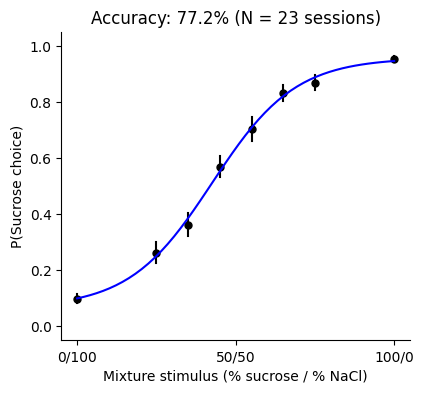

In [6]:
fig, ax = plt.subplots(figsize=(4.5, 4));
mean_ = np.mean(p_left, axis=0)
std_ = np.std(p_left, axis=0) / np.sqrt(p_left.shape[0])
for i_val in range(len(mean_)):
    ax.plot([unique_stims[i_val], unique_stims[i_val]], [mean_[i_val] - std_[i_val], mean_[i_val] + std_[i_val]], 'k');
    ax.plot(unique_stims[i_val], mean_[i_val], '.k', markersize=10);
    
psycho_res = fit_psychometric(unique_stims, mean_)
ax.plot(psycho_res['x'], psycho_res['y'], 'b');

# fun_psycho = lambda x, p0, p1, p2, p3: (p0 - p3) / (1 + np.exp(-p1 * (x - p2))) + p3
# p0 = [1, 0.1, 50, 0]
# try:
#     p, _ = scipy.optimize.curve_fit(
#         fun_psycho, 
#         unique_stims, 
#         mean_, 
#         p0=p0, 
#         bounds=([0, 0, 15, 0], [1, np.inf, 85, 1])
#     )
#     ax.plot(np.linspace(0, 100), fun_psycho(np.linspace(0, 100), *p), 'b');
# except:
#     print('Psychometric fitting failed...')
#     ax.plot(np.linspace(0, 100), fun_psycho(np.linspace(0, 100), *p0), 'b');

ax.set_xticks([0, 50, 100]);
ax.set_xticklabels(['0/100', '50/50', '100/0']);
ax.set_ylim([-0.05, 1.05]);
ax.set_xlabel('Mixture stimulus (% sucrose / % NaCl)');
ax.set_ylabel('P(Sucrose choice)');
ax.set_title('Accuracy: {:.1f}% (N = {} sessions)'.format(100 * perf_overall.mean(), n_sessions));
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);

# Figure 1B
# plt.savefig('plots/experimental/task_performance.pdf');

### Ensemble size statistics

In [7]:
ensemble_sizes = [all_data[session][0].shape[1] for session in included_sessions]

print('Minimum ensemble size: {}'.format(np.min(ensemble_sizes)))
print('Maximum ensemble size: {}'.format(np.max(ensemble_sizes)))
print('Average ensemble size: {:.1f}'.format(np.mean(ensemble_sizes)))
print('Median ensemble size: {:.1f}'.format(np.median(ensemble_sizes)))
print('Total pseudo-population size: {}'.format(np.sum(ensemble_sizes)))

Minimum ensemble size: 7
Maximum ensemble size: 68
Average ensemble size: 27.2
Median ensemble size: 27.0
Total pseudo-population size: 626


### Example single-trial multi-neuron raster plot

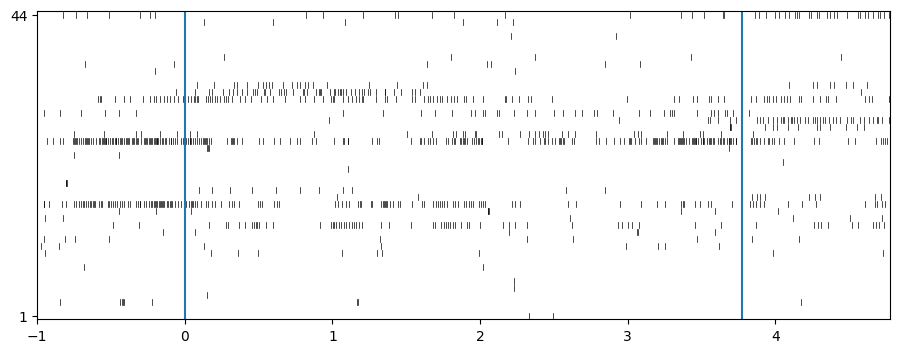

In [8]:
ex_session = included_sessions[1]
i_trial = 0

# behavior timestamps
trial_starts_correct = data['data_all'][0, ex_session][9]
trial_starts_error = data['data_all'][0, ex_session][10]
trial_starts = list(trial_starts_correct) + list(trial_starts_error)
sampling_events_correct = data['data_all'][0, ex_session][11]
sampling_events_error = data['data_all'][0, ex_session][12]
sampling_events = list(sampling_events_correct) + list(sampling_events_error)
IEIs_correct = data['data_all'][0, ex_session][15]
IEIs_error = data['data_all'][0, ex_session][16]
IEIs = list(IEIs_correct) + list(IEIs_error)

n_neurons = len(data['data_all'][0, ex_session][-1])
    
fig, ax = plt.subplots(figsize=(11, 4));
trial_start = trial_starts[i_trial]
sampling_event = sampling_events[i_trial]
IEI = IEIs[i_trial]
for i_neuron in range(n_neurons):
    spike_train = data['data_all'][0, ex_session][-1][i_neuron][0][0]
    train = spike_train - (trial_start + sampling_event)
    train = train[(train >= -1) & (train <= IEI + 1)]
    x, y = raster_format(train, i_neuron + 1)
    ax.plot(x, y, 'k', linewidth=0.5);
ax.set_xlim([-1, IEI + 1]);
ax.set_yticks([1, n_neurons]);
ax.set_ylim([0.5, n_neurons + 0.5]);
ax.axvline(0);
ax.axvline(IEI);

# Figure 1E
# plt.savefig('plots/experimental/multineuron_raster_session_{}_trial_{}.pdf'.format(ex_session, i_trial));

### Population PSTH

In [9]:
auROC = False
z_score = False
smooth_type = 'gaussian'
smooth_width = 11

rs = []

for i_session in included_sessions:
    
    X, y_conc, y_choice, y_outcome, _ = all_data[i_session]
    
    # smooth individual trials before averaging
    X_smooth = X[y_outcome == 1, :, :]
    for i in range(X_smooth.shape[0]):
        for j in range(X_smooth.shape[1]):
            X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)

    # pseudo-population PSTHs
    for i_neuron in range(X_smooth.shape[1]):
        if auROC:
            r = delta_auROC(
                X_smooth[:, i_neuron, :],
                np.tile(X_smooth[:, i_neuron, 0].mean(axis=1).reshape([-1, 1]), (1, X_smooth.shape[2]))
            ).reshape([1, -1]) 
        else:
            r = X_smooth[:, i_neuron, :].mean(axis=0).reshape([1, -1])
            if z_score:
                r = (r- r.mean()) / np.sqrt(r.var())
        rs.append(r)
        
rs = np.vstack(rs)
rs_mean = rs.mean(axis=0)
rs_stderr = np.sqrt(np.var(rs, axis=0)) / np.sqrt(rs.shape[0])

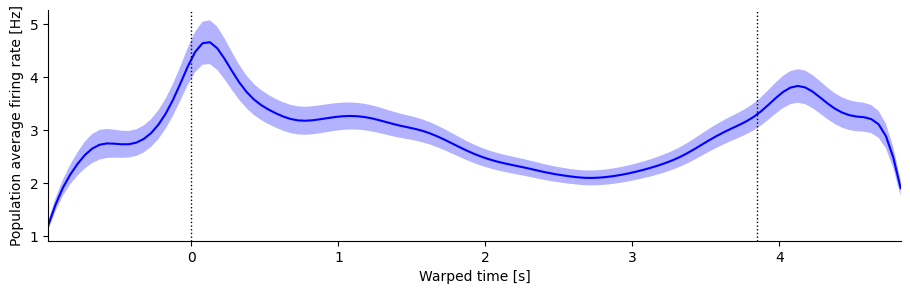

In [10]:
fig, ax = plt.subplots(figsize=(11, 3));
patch = plt.Polygon(
    [[t[i], rs_mean[i] - rs_stderr[i]] for i in range(len(t))] + \
    [[t[i], rs_mean[i] + rs_stderr[i]] for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
ax.add_patch(patch);
ax.plot(t, rs_mean, 'b', linewidth=1.5);
ax.axvline(0, color='k', linestyle=':', linewidth=1);
ax.axvline(IEI_mean_all, color='k', linestyle=':', linewidth=1);
ax.set_xlabel('Warped time [s]');
ax.set_ylabel('Population average firing rate [Hz]');
ax.set_xlim([t[0], t[-1]]);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);

# Figure 2A
# plt.savefig('plots/experimental/pseudopop_PSTH.pdf');

In [11]:
print('Max mean firing rate during sampling:')
r_max_sampling = np.max(rs_mean[(t >= 0) & (t < 0.5)])
t_max_sampling = t[int(np.argmax((t >= 0) & (t < 0.5) & (rs_mean == r_max_sampling)))]
print('t = {:.4f}, r = {:.2f}'.format(t_max_sampling, r_max_sampling))
print('Max mean firing rate during delay:')
r_max_delay = np.max(rs_mean[(t >= IEI_mean_all - 0.5) & (t < IEI_mean_all)])
t_max_delay = t[int(np.argmax((t >= IEI_mean_all - 0.5) & (t < IEI_mean_all) & (rs_mean == r_max_delay)))]
print('t = {:.4f} ({:.4f} before decision), r = {:.2f}'.format(t_max_delay, IEI_mean_all - t_max_delay, r_max_delay))
print('Max mean firing rate post-decision:')
r_max_post = np.max(rs_mean[(t > IEI_mean_all)])
t_max_post = t[int(np.argmax((t > IEI_mean_all) & (rs_mean == r_max_post)))]
print('t = {:.4f} ({:.4f} after decision), r = {:.2f}'.format(t_max_post, t_max_post - IEI_mean_all, r_max_post))

Max mean firing rate during sampling:
t = 0.1250, r = 4.66
Max mean firing rate during delay:
t = 3.8250 (0.0260 before decision), r = 3.25
Max mean firing rate post-decision:
t = 4.1250 (0.2740 after decision), r = 3.84


### auROC-normalized differential firing rates

In [12]:
smooth_type = 'gaussian'
smooth_width = 11

y1 = np.empty((0, len(t)))
y2 = np.empty((0, len(t)))
y1_tmax, y2_tmax = [], []
for sess in included_sessions:
    X, y_conc, y_choice, y_outcome, t = all_data[sess]
    # smooth individual trials before averaging
    X_smooth = X.copy()
    for i in range(X_smooth.shape[0]):
        for j in range(X_smooth.shape[1]):
            X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
    for neuron in range(X_smooth.shape[1]):
        x1 = np.empty((0, len(t)))
        x2 = np.empty((0, len(t)))
        for i_stim, stim in enumerate(unique_stims):
            trial_mask = (y_conc == stim) & (y_outcome == 1)
            if (stim < 50):
                x1 = np.vstack((x1, X_smooth[trial_mask, neuron, :]))
            else:
                x2 = np.vstack((x2, X_smooth[trial_mask, neuron, :]))
        dauROC = delta_auROC(x1, x2)
        tmax = np.argmax(abs(dauROC - 0.5))
        dauROC_max = dauROC[tmax]
        if dauROC_max > 0.5:
            y1 = np.vstack((y1, dauROC))
            y1_tmax.append(tmax)
        else:
            y2 = np.vstack((y2, dauROC))
            y2_tmax.append(tmax)
ind = np.argsort(y1_tmax)
y1 = y1[ind[::-1], :]
ind = np.argsort(y2_tmax)
y2 = y2[ind[::-1], :]

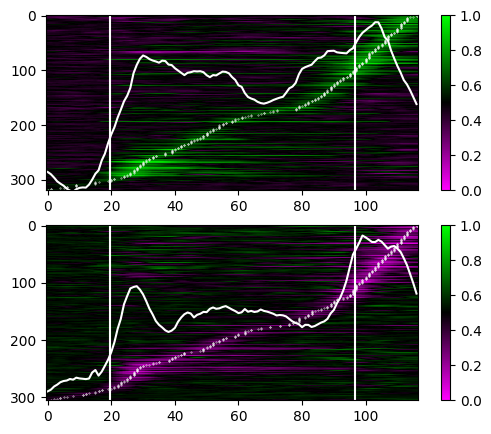

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(6, 5));
cmap = LinearSegmentedColormap.from_list('my_cmap', [(0, [1, 0, 1]), (0.5, [0, 0, 0]), (1, [0, 1, 0])])
axes[0].imshow(y1, cmap=cmap, aspect='auto');
mean_ = (y1 - 0.5).mean(axis=0)
mean_ = (y1.shape[0] - 1) - (mean_) / (0.08) * (y1.shape[0] - 1) # re-scale y-axis to [0, 0.08]
axes[0].plot(mean_, 'w');
axes[0].plot(np.array(y1_tmax)[np.argsort(y1_tmax)], np.arange(len(y1_tmax))[::-1], '.', color='w', markersize=0.6);
axes[0].set_ylim([y1.shape[0] - 0.5, -0.5]);

axes[1].imshow(y2, cmap=cmap, aspect='auto');
mean_ = (0.5 - y2).mean(axis=0)
mean_ = (y2.shape[0] - 1) - (mean_) / (0.08) * (y2.shape[0] - 1) # re-scale y-axis to [0, 0.08]
axes[1].plot(mean_, 'w');
axes[1].plot(np.array(y2_tmax)[np.argsort(y2_tmax)], np.arange(len(y2_tmax))[::-1], '.', color='w', markersize=0.6);

for ax in axes:
    ax.axvline(np.argmax(t >= 0) - 0.5, color='w');
    ax.axvline(np.argmax(t >= IEI_mean_all) - 0.5, color='w');
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=axes[0]);
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=axes[1]);

# Figure 2B
# plt.savefig('plots/experimental/heatmap.pdf');

In [14]:
# fig, ax = plt.subplots(figsize=(6, 2.5));
# mean_ = (0.5 - y2).mean(axis=0)
# ax.plot(t, mean_, 'k');
# ax.axvline(0, color='k');
# ax.axvline(IEI_mean_all, color='k');
# ax.set_ylim([0, 0.08]);
# ax.set_xlim([t[0], t[-1]]);

# plt.savefig('plots/experimental/heatmap_scale.pdf');

In [15]:
print('# NaCl-preferring:', y1.shape[0])
print('# Sucrose-preferring:', y2.shape[0])
print('Binomial test p = {:.4f}\n'.format(scipy.stats.binomtest(y1.shape[0], y1.shape[0] + y2.shape[0]).pvalue))

print('Maximum mean auROC for NaCl-preferring in first half:')
print('{:.4f}'.format(max(y1.mean(axis=0)[np.arange(y1.shape[1]) < y1.shape[1] / 2] - 0.5)))
print('Maximum mean auROC for NaCl-preferring:')
print('{:.4f}'.format(max(y1.mean(axis=0) - 0.5)))
print('Maximum mean auROC for sucrose-preferring in first half:')
print('{:.4f}'.format(max(0.5 - y2.mean(axis=0)[np.arange(y2.shape[1]) < y2.shape[1] / 2])))
print('Maximum mean auROC for sucrose-preferring:')
print('{:.4f}'.format(max(0.5 - y2.mean(axis=0))))

# NaCl-preferring: 320
# Sucrose-preferring: 306
Binomial test p = 0.6034

Maximum mean auROC for NaCl-preferring in first half:
0.0617
Maximum mean auROC for NaCl-preferring:
0.0769
Maximum mean auROC for sucrose-preferring in first half:
0.0522
Maximum mean auROC for sucrose-preferring:
0.0754


In [16]:
peaks_NaCl = np.max(y1 - 0.5, axis=1)
peaks_sucrose = np.max(0.5 - y2, axis=1)
results = scipy.stats.mannwhitneyu(peaks_NaCl, peaks_sucrose)
print('Mann Whitney U on difference in peaks p = {:.4f}'.format(results.pvalue))

Mann Whitney U on difference in peaks p = 0.8511


### Pseudo-population activity distances between trial types

In [17]:
smooth_type = 'gaussian'
smooth_width = 11

# format pseudo-pop data matrix, shape: (n_stims * n_t) X (n_neurons)
X_pseudo = np.empty((len(unique_stims) * len(t), 0))
for sess in included_sessions:
    X, y_conc, y_choice, y_outcome, t = all_data[sess]
    # smooth individual trials before averaging
    X_smooth = X.copy()
    for i in range(X_smooth.shape[0]):
        for j in range(X_smooth.shape[1]):
            X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
    for neuron in range(X_smooth.shape[1]):
        x1 = np.empty((0, 1))
        for i_stim, stim in enumerate(unique_stims):
            trial_mask = (y_conc == stim) & (y_outcome == 1)
            psth = X_smooth[trial_mask, neuron, :].mean(axis=0)
            x1 = np.vstack((x1, psth.reshape(-1, 1)))
        X_pseudo = np.hstack((X_pseudo, x1))     

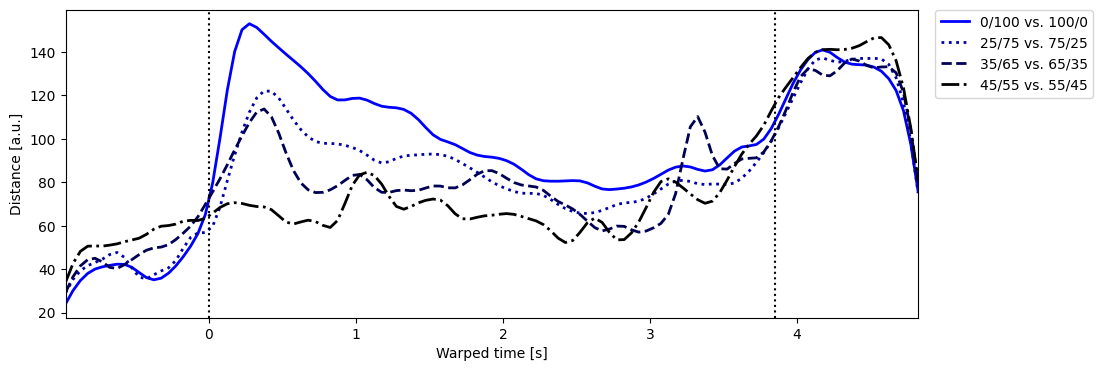

In [18]:
distance = 'euclidean'

if distance == 'euclidean':
    dist = lambda x, y: dist_euclidean(x, y)
elif distance == 'cosine':
    dist = lambda x, y: dist_cosine(x, y)
        
color_gradient = np.hstack([
    np.linspace(0.0, 0.0, 4).reshape((-1, 1)),
    np.linspace(0.0, 0.0, 4).reshape((-1, 1)),
    np.linspace(1.0, 0.0, 4).reshape((-1, 1))
])

line_styles = ['-', ':', '--', '-.']

fig, ax = plt.subplots(figsize=(11, 4));
for i_stim in range(len(unique_stims) // 2):
    ind = i_stim * len(t)
    x1 =  X_pseudo[ind:(ind + len(t)), :]
    ind_pair = (len(unique_stims) - i_stim - 1) * len(t)
    x2 = X_pseudo[ind_pair:(ind_pair + len(t))]
    d = [dist(x1[i_t, :], x2[i_t, :]) for i_t in range(len(t))]
    ax.plot(t, d, color=color_gradient[i_stim, :], linewidth=2, linestyle=line_styles[i_stim]);
ax.axvline(0, color='k', linestyle=':');
ax.axvline(IEI_mean_all, color='k', linestyle=':');
ax.set_xlim([t[0], t[-1]]);
ax.set_xlabel('Warped time [s]');
ax.set_ylabel('Distance [a.u.]');
ax.legend(['0/100 vs. 100/0', '25/75 vs. 75/25', '35/65 vs. 65/35', '45/55 vs. 55/45'], 
          bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.);

# Figure 3A
# plt.savefig('plots/experimental/distance_pairs.pdf');

### Dimensionality reduction: t-SNE

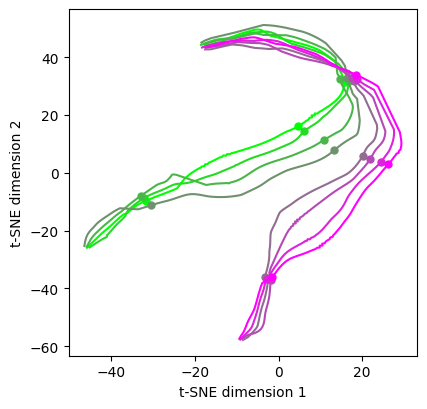

In [19]:
tsne = TSNE(n_components=2, metric=distance)
X_pseudo_embed = tsne.fit_transform(X_pseudo)

fig, ax = plt.subplots(figsize=(4.5, 4.5));
for i_stim in range(len(unique_stims)):
    ind = i_stim * len(t)
    x, y = X_pseudo_embed[ind:(ind + len(t)), 0], X_pseudo_embed[ind:(ind + len(t)), 1]
    # solid curve plot
    ax.plot(x, y, color=colors[i_stim, :]);
    # quiver/arrow plot
    # ax.quiver(x[:-1], y[:-1], np.diff(x), np.diff(y), color=colors[i_stim, :], 
    #                angles='xy', scale_units='xy', scale=1);
    ind = np.argmax(t >= 0)
    ax.plot(x[ind], y[ind], '.', color=colors[i_stim, :], markersize=10);
    ind = np.argmax(t >= 1)
    ax.plot(x[ind], y[ind], '.', color=colors[i_stim, :], markersize=10);
    ind = np.argmax(t >= IEI_mean_all)
    ax.plot(x[ind], y[ind], '.', color=colors[i_stim, :], markersize=10);
ax.set_xlabel('t-SNE dimension 1');
ax.set_ylabel('t-SNE dimension 2');

# Figure 3B
# plt.savefig('plots/experimental/tsne.pdf');

### Dimensionality reduction: dPCA

In [20]:
smooth_type = 'gaussian'
smooth_width = 11

# get maximum number of trials for any parameter combination across sessions
max_num_trials = 0
n_neurons_pseudo = 0
flagged_sessions = []
for i_session in included_sessions:
    X, y_conc, y_choice, _, _ = all_data[i_session]
    n_neurons_pseudo += X.shape[1]
    for stim in unique_stims:
        for choice in [0, 1]:
            n = ((y_conc == stim) & (y_choice == choice)).sum()
            if (n == 0) and (i_session not in flagged_sessions):
                flagged_sessions.append(i_session)
            max_num_trials = max(max_num_trials, n)
            
# assemble pseudo-population trial-by-trial tensor
# X_pseudo_tensor: (trials x neurons x stimuli x decisions x time)
X_pseudo_tensor = np.full([max_num_trials, n_neurons_pseudo, len(unique_stims), 2, len(t)], np.nan)
n_neurons_cumul = 0
for sess in included_sessions:
    X, y_conc, y_choice, y_outcome, t = all_data[sess]
    n_neurons = X.shape[1]
    # smooth individual trials
    X_smooth = X.copy()
    for i in range(X_smooth.shape[0]):
        for j in range(X_smooth.shape[1]):
            X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
    ###----------------------------------------------------------------------------------------------------
    if sess in flagged_sessions:
        ### issue: some data are missing for this session
        ### workaround: fit a simple linear model to existing data and use it to predict the missing parts
        predictors = np.vstack([
            y_conc.reshape([1, -1]),
            y_choice.reshape([1, -1]),
            (y_conc * y_choice).reshape([1, -1]),
            np.ones([1, X.shape[0]])
        ])
        betas = [[scipy.linalg.pinv(predictors @ predictors.T) @ predictors @ X_smooth[:, i_n, i_t].reshape([-1, 1])
                  for i_t in range(len(t))] for i_n in range(n_neurons)]
    ###-----------------------------------------------------------------------------------------------------
    for i_stim, stim in enumerate(unique_stims):
        for i_choice, choice in enumerate([0, 1]):
            trial_mask = (y_conc == stim) & (y_choice == choice)
            n_trials = trial_mask.sum()
            # we need at least 2 trials per condition for the cross-validation procedure
            if n_trials == 0:
                ### use the linear model's prediction and copy it ------------------------------------------
                for i_n in range(n_neurons):
                    for i_t in range(len(t)):
                        r = max((betas[i_n][i_t].flatten() * np.array([stim, choice, stim * choice, 1])).sum(), 0)
                        X_pseudo_tensor[:2, n_neurons_cumul + i_n, i_stim, i_choice, i_t] = np.array([r, r])
                ### ----------------------------------------------------------------------------------------
            elif n_trials == 1:
                # copy the only trial
                X_pseudo_tensor[:2, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                    np.concatenate([
                    X_smooth[trial_mask, :, :].reshape([1, n_neurons, len(t)]),
                    X_smooth[trial_mask, :, :].reshape([1, n_neurons, len(t)])],
                    axis=0)
            else:
                # use available trials
                X_pseudo_tensor[:n_trials, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                    X_smooth[trial_mask, :, :]
    n_neurons_cumul += n_neurons
    
# get the pseudo-population trial-averaged (PSTH) tensor
X_pseudo_psth_tensor = np.nanmean(X_pseudo_tensor, axis=0)

In [21]:
# do the dPCA
try:
    with open('data/experimental/dPCA_Z.pkl', 'rb') as file:
        Z = pickle.load(file)
        file.close()
except:
    dpca = dPCA.dPCA(labels='sdt', regularizer='auto', join={'st': ['s', 'st'], 'dt': ['d', 'dt'], 'sdt': ['sd', 'sdt']})
    dpca.protect = ['t']
    Z = dpca.fit_transform(X_pseudo_psth_tensor, X_pseudo_tensor)
    with open('data/experimental/dPCA_Z.pkl', 'wb') as file:
        pickle.dump(Z, file)
        file.close()

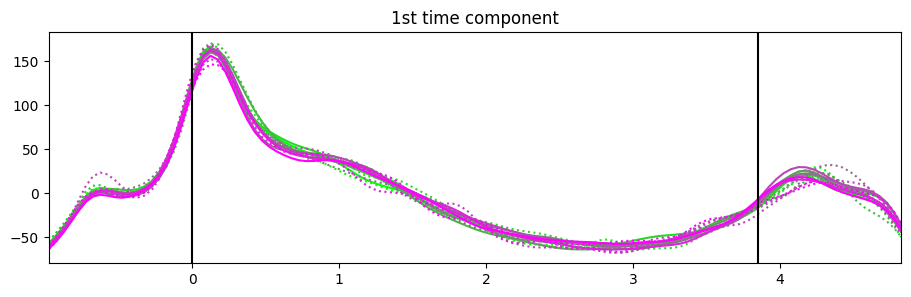

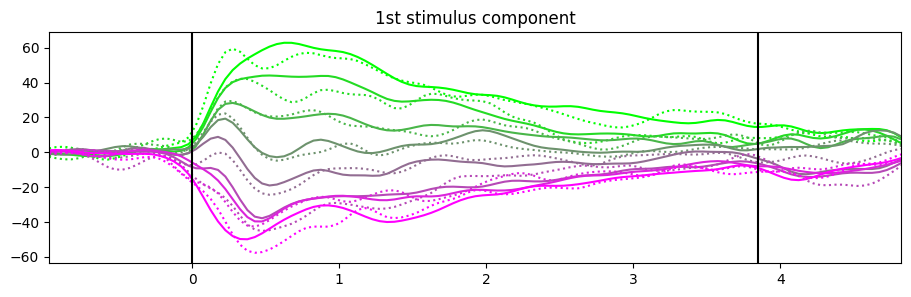

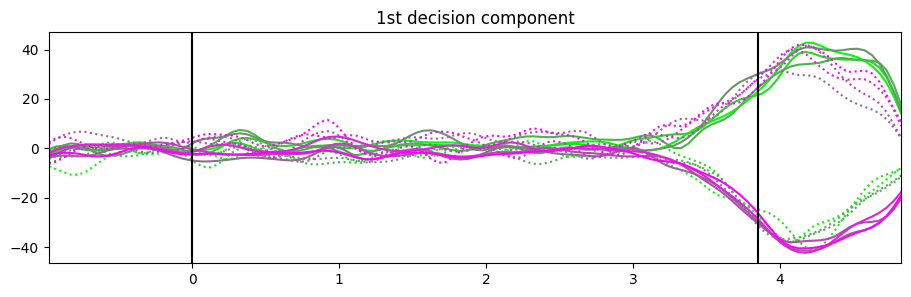

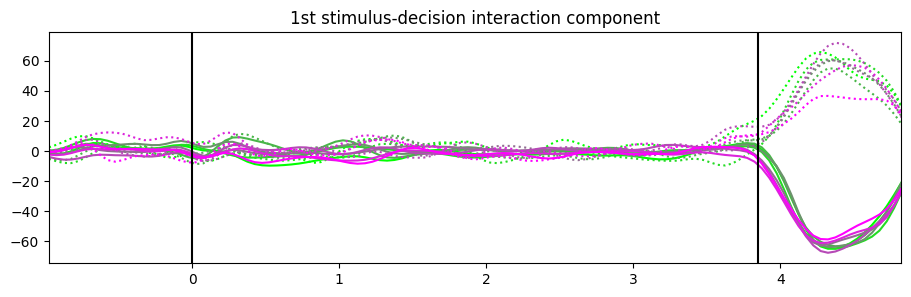

In [22]:
# plots

# time component ('t')
fig, ax = plt.subplots(figsize=(11, 3));
for i_stim, stim in enumerate(unique_stims):
    for i_choice, choice in enumerate([0, 1]):
        z = Z['t'][0, i_stim, i_choice, :]
        color = colors[i_stim, :]
        style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
        ax.plot(t, z, color=color, linestyle=style);
ax.set_title('1st time component');
ax.set_xlim([t[0], t[-1]]);
ax.axvline(0, color='k');
ax.axvline(IEI_mean_all, color='k');
    
# stimulus component ('st')
fig, ax = plt.subplots(figsize=(11, 3));
for i_stim, stim in enumerate(unique_stims):
    for i_choice, choice in enumerate([0, 1]):
        z = Z['st'][0, i_stim, i_choice, :]
        color = colors[i_stim, :]
        style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
        ax.plot(t, z, color=color, linestyle=style);
ax.set_title('1st stimulus component');
ax.set_xlim([t[0], t[-1]]);
ax.axvline(0, color='k');
ax.axvline(IEI_mean_all, color='k');

# Figure 3C
# plt.savefig('plots/experimental/dPCA_stimulus.pdf');

# decision component ('dt')
fig, ax = plt.subplots(figsize=(11, 3));
for i_stim, stim in enumerate(unique_stims):
    for i_choice, choice in enumerate([0, 1]):
        z = Z['dt'][0, i_stim, i_choice, :]
        color = colors[i_stim, :]
        style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
        ax.plot(t, z, color=color, linestyle=style);
ax.set_title('1st decision component');
ax.set_xlim([t[0], t[-1]]);
ax.axvline(0, color='k');
ax.axvline(IEI_mean_all, color='k');

# Figure 3D
# plt.savefig('plots/experimental/dPCA_choice.pdf');

# stimulus-decision interaction component ('sdt')
fig, ax = plt.subplots(figsize=(11, 3));
for i_stim, stim in enumerate(unique_stims):
    for i_choice, choice in enumerate([0, 1]):
        z = Z['sdt'][0, i_stim, i_choice, :]
        color = colors[i_stim, :]
        style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
        ax.plot(t, z, color=color, linestyle=style);
ax.set_title('1st stimulus-decision interaction component');
ax.set_xlim([t[0], t[-1]]);
ax.axvline(0, color='k');
ax.axvline(IEI_mean_all, color='k');

### Decoding

In [23]:
try:
    
    with open('data/experimental/session_accuracies.pkl', 'rb') as file:
        session_accuracies = pickle.load(file)
        file.close()
        session_accuracies_stimulus = session_accuracies['stimulus']
        session_accuracies_choice = session_accuracies['choice']
        
except:

    smooth_type = 'gaussian'
    smooth_width = 11
    distance = 'euclidean'

    if distance == 'euclidean':
        dist = lambda x, y: dist_euclidean(x, y)
    elif distance == 'cosine':
        dist = lambda x, y: dist_cosine(x, y)
    elif distance == 'correlation':
        dist = lambda x, y: dist_correlation(x, y)

    # session-by-session decoding
    session_accuracies_stimulus = []
    session_accuracies_choice = []
    for sess in included_sessions:
        X, y_conc, y_choice, y_outcome, t = all_data[sess]
        # smooth individual trials before inputting to decoder
        X_smooth = X.copy()
        for i in range(X_smooth.shape[0]):
            for j in range(X_smooth.shape[1]):
                X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
        accuracy_stimulus = min_dist_classify(X_smooth, y_conc, dist)
        accuracy_choice = min_dist_classify(X_smooth, y_choice, dist)
        session_accuracies_stimulus.append(accuracy_stimulus)
        session_accuracies_choice.append(accuracy_choice)
        
    with open('data/experimental/session_accuracies.pkl', 'wb') as file:
        pickle.dump({
            'stimulus': session_accuracies_stimulus,
            'choice': session_accuracies_choice,
        }, file)
        file.close()

Peak decoding:
acc = 31.0%, t = 0.4250


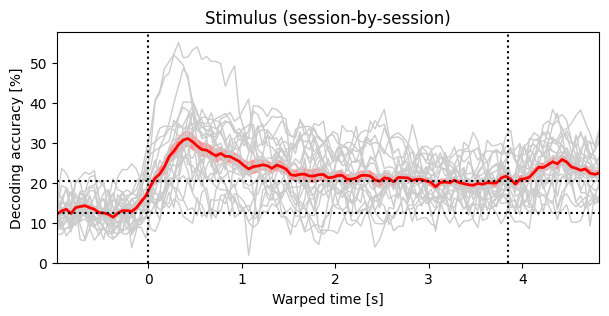

In [24]:
fig, ax = plt.subplots(figsize=(7, 3));
session_balanced_accuracies_stimulus = np.zeros((n_sessions, len(t)))
chance_stimulus = 1 / len(unique_stims)
for i_sess, sess in enumerate(included_sessions):
    acc = session_accuracies_stimulus[sess]
    ax.plot(t, 100 * acc.mean(axis=0), color=[0.8, 0.8, 0.8], linewidth=1);
    session_balanced_accuracies_stimulus[i_sess, :] = acc.mean(axis=0)
mean = (100 * session_balanced_accuracies_stimulus).mean(axis=0)
std = (100 * session_balanced_accuracies_stimulus).std(axis=0) / np.sqrt(session_balanced_accuracies_stimulus.shape[0])
patch = plt.Polygon(
    [(t[i], mean[i] - std[i]) for i in range(len(t))] + [(t[i], mean[i] + std[i]) for i in range(len(t))[::-1]],
    facecolor='r',
    edgecolor=None,
    alpha=0.4
)
ax.add_patch(patch);
ax.plot(t, mean, color='r', linewidth=2);
ax.axvline(0, color='k', linestyle=':');
ax.axvline(IEI_mean_all, color='k', linestyle=':');
# chance level
ax.axhline(100 * chance_stimulus, color='k', linestyle=':');
# 0.01 significance threshold for N = 137
ax.axhline(binomial_threshold(alpha=0.01, N=137, chance=chance_stimulus, n_tails=1), color='k', linestyle=':'); 
ax.set_xlim([t[0], t[-1]]);
ax.set_ylim([0, ax.get_ylim()[1]]);
ax.set_xlabel('Warped time [s]');
ax.set_ylabel('Decoding accuracy [%]');
ax.set_title('Stimulus (session-by-session)');

# Figure 2C
# plt.savefig('plots/experimental/decoding_stimulus.pdf');

decode_max = np.max(mean)
t_max = t[int(np.argmax(mean == decode_max))]
print('Peak decoding:')
print('acc = {:.1f}%, t = {:.4f}'.format(decode_max, t_max))

Peak decoding:
acc = 81.9%, t = 3.9250, 0.0740 s after decision


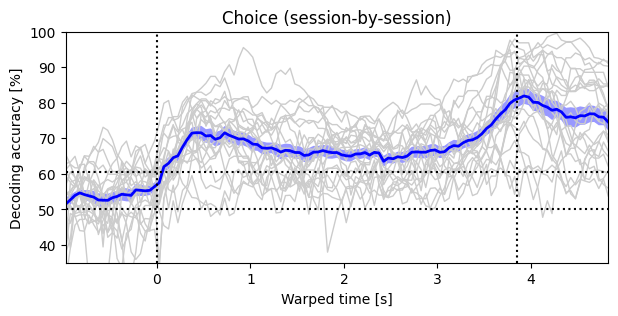

In [25]:
fig, ax = plt.subplots(figsize=(7, 3));
session_balanced_accuracies_choice = np.zeros((n_sessions, len(t)))
chance_choice = 1 / 2
for i_sess, sess in enumerate(included_sessions):
    acc = session_accuracies_choice[sess]
    y = 100 * acc.mean(axis=0)
    ax.plot(t, y, color=[0.8, 0.8, 0.8], linewidth=1);
    session_balanced_accuracies_choice[i_sess, :] = acc.mean(axis=0)
mean = (100 * session_balanced_accuracies_choice).mean(axis=0)
std = (100 * session_balanced_accuracies_choice).std(axis=0) / np.sqrt(session_balanced_accuracies_choice.shape[0])
patch = plt.Polygon(
    [(t[i], mean[i] - std[i]) for i in range(len(t))] + [(t[i], mean[i] + std[i]) for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.4
)
ax.add_patch(patch);
ax.plot(t, mean, color='b', linewidth=2);
ax.axvline(0, color='k', linestyle=':');
ax.axvline(IEI_mean_all, color='k', linestyle=':');
# chance level
ax.axhline(100 * chance_choice, color='k', linestyle=':');
# 0.01 significance threshold for N=137
ax.axhline(binomial_threshold(alpha=0.01, N=137, chance=0.5, n_tails=1), color='k', linestyle=':');
ax.set_xlim([t[0], t[-1]]);
ax.set_ylim([35, 100]);
ax.set_xlabel('Warped time [s]');
ax.set_ylabel('Decoding accuracy [%]');
ax.set_title('Choice (session-by-session)');

# Figure 2D
# plt.savefig('plots/experimental/decoding_choice.pdf');

decode_max = np.max(mean)
t_max = t[int(np.argmax(mean == decode_max))]
print('Peak decoding:')
print('acc = {:.1f}%, t = {:.4f}, {:.4f} s after decision'.format(decode_max, t_max, t_max - IEI_mean_all))

In [26]:
# 2-way within-subjects ANOVA on decoding accuracy

n_subjects = n_sessions
time = ['Sampling', 'Delay']
decoder = ['Stimulus', 'Choice']
col_subject = [i for i in included_sessions] * (len(time) * len(decoder))
col_time, col_decoder, col_measurement = [], [], []

for time_i in time:
    for decoder_i in decoder:
        col_time += [time_i] * n_subjects
        col_decoder += [decoder_i] * n_subjects
        if decoder_i == 'Stimulus':
            x = session_balanced_accuracies_stimulus - chance_stimulus
        elif decoder_i == 'Choice':
            x = session_balanced_accuracies_choice - chance_choice
        if time_i == 'Sampling':
            col_measurement += list(x[:, 20:30].mean(axis=1))
        elif time_i == 'Delay':
            col_measurement += list(x[:, -30:-20].mean(axis=1))

df = pd.DataFrame({
    'id': col_subject,
    'iv1': col_time,
    'iv2': col_decoder,
    'dv': col_measurement
})

# Perform repeated measures ANOVA
res_anova = rmAnova2Way(df)

SSE_1b = 0.0031, SSE_1w = 0.0746, F_1 = 0.9096, p_1 = 0.3506
SSE_2b = 0.2298, SSE_2w = 0.0529, F_2 = 95.5009, p_2 = 0.0000
SSE_12b = 0.1230, SSE_12w = 0.0653, F_12 = 41.4426, p_12 = 0.0000


### Single neuron responsivity and selectivity tests

In [27]:
try:
    with open('data/experimental/responsivity_and_selectivity.pkl', 'rb') as file:
        res = pickle.load(file)
        file.close()
except:
    res = responsive_and_selective_tests(data, included_sessions, 
                                         width=0.5, 
                                         correct_only=True, 
                                         t_base=2.5, t_base_rel_to='T', 
                                         d_base=5.0, d_base_rel_to='D',
                                         bin_size=bin_size)
    with open('data/experimental/responsivity_and_selectivity.pkl', 'wb') as file:
        pickle.dump(res, file)
        file.close()

alpha = 0.01

count = 0
is_taste_responsive_list = []
is_taste_selective_list = []
is_delay_responsive_list = []
is_delay_selective_list = []

for i_session in res:
    is_taste_responsive_i = []
    is_taste_selective_i = []
    is_delay_responsive_i = []
    is_delay_selective_i = []
    for i_neuron in res[i_session]:
        count += 1
        p = res[i_session][i_neuron]['p_responsive_sampling']
        is_taste_responsive_i.append(p < alpha)
        p = res[i_session][i_neuron]['p_responsive_delay']
        is_delay_responsive_i.append(p < alpha)
        p = res[i_session][i_neuron]['p_selective_sampling']
        is_taste_selective_i.append(p < alpha)
        p = res[i_session][i_neuron]['p_selective_delay']
        is_delay_selective_i.append(p < alpha)
    is_taste_responsive_i = np.array(is_taste_responsive_i)
    is_delay_responsive_i = np.array(is_delay_responsive_i)
    is_taste_selective_i = is_taste_responsive_i & np.array(is_taste_selective_i) 
    is_delay_selective_i = is_delay_responsive_i & np.array(is_delay_selective_i)
    is_taste_responsive_list.append(is_taste_responsive_i.copy())
    is_delay_responsive_list.append(is_delay_responsive_i.copy())
    is_taste_selective_list.append(is_taste_selective_i.copy())
    is_delay_selective_list.append(is_delay_selective_i.copy())
is_taste_responsive = np.hstack(is_taste_responsive_list)
is_taste_selective = np.hstack(is_taste_selective_list)
is_delay_responsive = np.hstack(is_delay_responsive_list)
is_delay_selective = np.hstack(is_delay_selective_list)
count_responsive_sampling = is_taste_responsive.sum()
count_selective_sampling = is_taste_selective.sum()
count_responsive_delay = is_delay_responsive.sum() 
count_selective_delay = is_delay_selective.sum()
count_responsive_both = (is_taste_responsive & is_delay_responsive).sum() 
            
print('Sampling responsive: {}/{} ({:.1f}%)'.format(
    count_responsive_sampling, count, 100 * count_responsive_sampling / count
))
print('Sampling selective: {}/{} ({:.1f}%)'.format(
    count_selective_sampling, count_responsive_sampling, 100 * count_selective_sampling / count_responsive_sampling
))
print('Delay responsive: {}/{} ({:.1f}%)'.format(
    count_responsive_delay, count, 100 * count_responsive_delay / count
))
print('Delay selective: {}/{} ({:.1f}%)'.format(
    count_selective_delay, count_responsive_delay, 100 * count_selective_delay / count_responsive_delay
))
print('Both responsive: {}/{} ({:.1f}%)'.format(
    count_responsive_both, count, 100 * count_responsive_both / count
))

Sampling responsive: 370/626 (59.1%)
Sampling selective: 93/370 (25.1%)
Delay responsive: 275/626 (43.9%)
Delay selective: 99/275 (36.0%)
Both responsive: 193/626 (30.8%)


In [28]:
print('Session | Neurons | Taste Responsive | Taste Selective | Delay Responsive | Delay Selective')
print('-------------------------------------------------------------------------------------------')
for i, sess in enumerate(res):
    print('{:7} | {:7} | {:16} | {:15} | {:16} | {:15}'
          .format(sess, 
                  len(is_taste_responsive_list[i]), 
                  is_taste_responsive_list[i].sum(), 
                  is_taste_selective_list[i].sum(),
                  is_delay_responsive_list[i].sum(),
                  is_delay_selective_list[i].sum()))

Session | Neurons | Taste Responsive | Taste Selective | Delay Responsive | Delay Selective
-------------------------------------------------------------------------------------------
      0 |      17 |                6 |               3 |                1 |               1
      1 |      44 |               28 |               6 |               19 |               7
      2 |      21 |               12 |               5 |                8 |               3
      3 |      48 |               30 |               9 |               23 |              12
      4 |      29 |               14 |               3 |               12 |               5
      5 |      68 |               43 |              10 |               35 |               7
      6 |      16 |                8 |               1 |                3 |               3
      7 |      41 |               26 |               9 |               25 |              12
      8 |      17 |                8 |               0 |                6 |     

### Single neuron response profile analysis ('beginning' vs. 'end')

In [29]:
## coding type beginning vs. end (no warping)

fit_options = [
    {
        'shape' : 'linear',
        'y_min' : 0,
        'y_max' : np.inf,
        'min_y_range' : 0
    },
    {
        'shape' : 'step',
        'midpoints' : [40, 50, 60],
        'min_y_range' : 0
    }
]

all_labels_beginning = []
all_labels_end = []
all_classifications_beginning = []
all_classifications_end = []

for i_session in included_sessions:   
    
    labels_beginning = []
    labels_end = []
    classifications_beginning = []
    classifications_end = []
    n_neurons = int(data['data_all'][0, i_session][6])
    
    # trial labels
    trial_stim_correct = data['data_all'][0, i_session][7]
    trial_stim_error = data['data_all'][0, i_session][8]
    y_conc = np.vstack((trial_stim_correct, trial_stim_error)).flatten()
    y_outcome = np.array([1 for _ in trial_stim_correct] + [0 for _ in trial_stim_error])

    # spike trains
    spike_trains = data['data_all'][0, i_session][-1]

    # behavior timestamps
    central_licks_correct = data['data_all'][0, i_session][9] + data['data_all'][0, i_session][11]
    central_licks_error = data['data_all'][0, i_session][10] + data['data_all'][0, i_session][12]
    central_licks = np.vstack((central_licks_correct, central_licks_error)).flatten()
    IEIs_correct = data['data_all'][0, i_session][15]
    IEIs_error = data['data_all'][0, i_session][16] 
    lateral_licks = central_licks + np.vstack((IEIs_correct, IEIs_error)).flatten()
    
    for i_neuron in range(n_neurons):
        spike_train = spike_trains[i_neuron][0][0]
        # beginning
        # form response profiles
        response_profile_correct = np.full(len(unique_stims), np.nan)
        response_profile_error = np.full(len(unique_stims), np.nan)
        for i_stim, stim in enumerate(unique_stims):
            trial_mask = (y_conc == stim) & (y_outcome == 1)
            if trial_mask.sum() > 0:
                response_profile_correct[i_stim] = np.mean([
                    ((spike_train - ts >= 0) & (spike_train - ts < 0.5)).sum() / 0.5 for ts in central_licks[trial_mask]
                ])
            trial_mask = (y_conc == stim) & (y_outcome == 0)
            if trial_mask.sum() > 0:
                response_profile_error[i_stim] = np.mean([
                    ((spike_train - ts >= 0) & (spike_train - ts < 0.5)).sum() / 0.5 for ts in central_licks[trial_mask]
                ])
        # fit shape templates
        fits = fit_shape_templates(unique_stims, response_profile_correct, fit_options)
        # classify
        classification = classify_fits(fits)
        classifications_beginning.append(classification)
        # parse label
        label = parse_label(classification, response_profile_correct, response_profile_error)
        labels_beginning.append(label)
        # end
        # form response profiles
        response_profile_correct = np.full(len(unique_stims), np.nan)
        response_profile_error = np.full(len(unique_stims), np.nan)
        for i_stim, stim in enumerate(unique_stims):
            trial_mask = (y_conc == stim) & (y_outcome == 1)
            if trial_mask.sum() > 0:
                response_profile_correct[i_stim] = np.mean([
                    ((spike_train - ts >= -0.5) & (spike_train - ts < 0)).sum() / 0.5 for ts in lateral_licks[trial_mask]
                ])
            trial_mask = (y_conc == stim) & (y_outcome == 0)
            if trial_mask.sum() > 0:
                response_profile_error[i_stim] = np.mean([
                    ((spike_train - ts >= -0.5) & (spike_train - ts < 0)).sum() / 0.5 for ts in lateral_licks[trial_mask]
                ])
        # fit shape templates
        fits = fit_shape_templates(unique_stims, response_profile_correct, fit_options)
        # classify
        classification = classify_fits(fits)
        classifications_end.append(classification)
        # parse label
        label = parse_label(classification, response_profile_correct, response_profile_error)
        labels_end.append(label)
    all_labels_beginning.append(labels_beginning)
    all_labels_end.append(labels_end)
    all_classifications_beginning.append(classifications_beginning)
    all_classifications_end.append(classifications_end)

Beginning:
    Linear: 31
    Perception: 10
    Choice: 0
    Other: 585
End:
    Linear: 22
    Perception: 12
    Choice: 25
    Other: 567


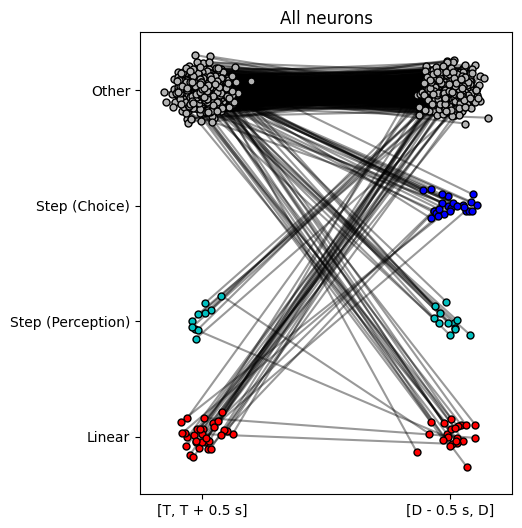

In [30]:
all_labels_beginning_pool = []
all_labels_end_pool = []
for i in range(len(all_labels_beginning)):
    all_labels_beginning_pool += all_labels_beginning[i]
    all_labels_end_pool += all_labels_end[i]
print('Beginning:')
print('    Linear:', sum([label == 'Linear' for label in all_labels_beginning_pool]))
print('    Perception:', sum([label == 'Step (Perception)' for label in all_labels_beginning_pool]))
print('    Choice:', sum([label == 'Step (Choice)' for label in all_labels_beginning_pool]))
print('    Other:', sum([label == 'Other' for label in all_labels_beginning_pool]))
print('End:')
print('    Linear:', sum([label == 'Linear' for label in all_labels_end_pool]))
print('    Perception:', sum([label == 'Step (Perception)' for label in all_labels_end_pool]))
print('    Choice:', sum([label == 'Step (Choice)' for label in all_labels_end_pool]))
print('    Other:', sum([label == 'Other' for label in all_labels_end_pool]))
x_beg = 1 + 0.2 * np.random.normal(size=len(all_labels_beginning_pool))
x_end = 5 + 0.2 * np.random.normal(size=len(all_labels_end_pool))
mapping = {
    'Linear': {'id': 1, 'color': 'r'},
    'Step (Perception)': {'id': 3, 'color': 'c'},
    'Step (Choice)': {'id': 5, 'color': 'b'},
    'Other': {'id': 7, 'color': [0.7, 0.7, 0.7]}
}
y_beg = np.array([mapping[label]['id'] for label in all_labels_beginning_pool])
y_beg_noise = 0.2 * np.random.normal(size=len(y_beg))
y_end = np.array([mapping[label]['id'] for label in all_labels_end_pool])
y_end_noise = 0.2 * np.random.normal(size=len(y_end))

fig, ax = plt.subplots(figsize=(4.8, 6));
for i in range(len(y_beg)):
    ax.plot([x_beg[i], x_end[i]], [y_beg[i] + y_beg_noise[i], y_end[i] + y_end_noise[i]], 'k', alpha=0.4);
for coding_type in mapping:
    id_ = mapping[coding_type]['id']
    color = mapping[coding_type]['color']
    ax.plot(x_beg[y_beg == id_], (y_beg + y_beg_noise)[y_beg == id_], '.', 
                 mfc=color, mec='k', markersize=10);
    ax.plot(x_end[y_end == id_], (y_end + y_end_noise)[y_end == id_], '.', 
                 mfc=color, mec='k', markersize=10);
ax.set_xticks([1, 5]);
ax.set_xticklabels(['[T, T + 0.5 s]', '[D - 0.5 s, D]']);
ax.set_xlim([0, 6]);
ax.set_yticks([mapping[key]['id'] for key in mapping]);
ax.set_yticklabels([key for key in mapping]);
ax.set_ylim([min([mapping[key]['id'] for key in mapping]) - 1, max([mapping[key]['id'] for key in mapping]) + 1]);
ax.set_title('All neurons');

# Figure 4B
# plt.savefig('plots/experimental/response_profiles_beginning_vs_end_tall.pdf');

In [31]:
# proportion of coding units in beginning vs. end
n1 = np.sum([label != 'Other' for label in all_labels_beginning_pool])
n2 = np.sum([label != 'Other' for label in all_labels_end_pool])
N = len(all_labels_beginning_pool)
observed = [[n1, N - n1], [n2, N - n2]]
_, p, _, _ = scipy.stats.chi2_contingency(observed, correction=False)
print('Proportion of coding units in beginning vs. end: {}/{} vs. {}/{} ... p = {:.4f}'.format(n1, N, n2, N, p))

# proportion of step-coding units in beginning vs. end
n1 = np.sum([label in ['Step (Perception)', 'Step (Choice)'] for label in all_labels_beginning_pool])
d1 = np.sum([label != 'Other' for label in all_labels_beginning_pool])
n2 = np.sum([label in ['Step (Perception)', 'Step (Choice)'] for label in all_labels_end_pool])
d2 = np.sum([label != 'Other' for label in all_labels_end_pool])
observed = [[n1, d1 - n1], [n2, d2 - n2]]
_, p, _, _ = scipy.stats.chi2_contingency(observed, correction=False)
print('Proportion of step-coding units in beginning vs. end: {}/{} vs. {}/{} ... p = {:.4f}'.format(n1, d1, n2, d2, p))

# proportion of linear-coding units in beginning vs. end
n1 = np.sum([label == 'Linear' for label in all_labels_beginning_pool])
d1 = np.sum([label != 'Other' for label in all_labels_beginning_pool])
n2 = np.sum([label == 'Linear' for label in all_labels_end_pool])
d2 = np.sum([label != 'Other' for label in all_labels_end_pool])
observed = [[n1, d1 - n1], [n2, d2 - n2]]
_, p, _, _ = scipy.stats.chi2_contingency(observed, correction=False)
print('Proportion of linear-coding units in beginning vs. end: {}/{} vs. {}/{} ... p = {:.4f}'.format(n1, d1, n2, d2, p))

# proportion of step-perception units in beginning vs. end
n1 = np.sum([label == 'Step (Perception)' for label in all_labels_beginning_pool])
d1 = np.sum([label != 'Other' for label in all_labels_beginning_pool])
n2 = np.sum([label == 'Step (Perception)' for label in all_labels_end_pool])
d2 = np.sum([label != 'Other' for label in all_labels_end_pool])
observed = [[n1, d1 - n1], [n2, d2 - n2]]
_, p, _, _ = scipy.stats.chi2_contingency(observed, correction=False)
print('Proportion of step-perception units in beginning vs. end: {}/{} vs. {}/{} ... p = {:.4f}'.format(n1, d1, n2, d2, p))

# proportion of step-choice units in beginning vs. end
n1 = np.sum([label == 'Step (Choice)' for label in all_labels_beginning_pool])
d1 = np.sum([label != 'Other' for label in all_labels_beginning_pool])
n2 = np.sum([label == 'Step (Choice)' for label in all_labels_end_pool])
d2 = np.sum([label != 'Other' for label in all_labels_end_pool])
observed = [[n1, d1 - n1], [n2, d2 - n2]]
_, p, _, _ = scipy.stats.chi2_contingency(observed, correction=False)
print('Proportion of step-choice units in beginning vs. end: {}/{} vs. {}/{} ... p = {:.4f}'.format(n1, d1, n2, d2, p))

Proportion of coding units in beginning vs. end: 41/626 vs. 59/626 ... p = 0.0606
Proportion of step-coding units in beginning vs. end: 10/41 vs. 37/59 ... p = 0.0002
Proportion of linear-coding units in beginning vs. end: 31/41 vs. 22/59 ... p = 0.0002
Proportion of step-perception units in beginning vs. end: 10/41 vs. 12/59 ... p = 0.6305
Proportion of step-choice units in beginning vs. end: 0/41 vs. 25/59 ... p = 0.0000


In [32]:
is_other_beginning = np.array([label == 'Other' for label in all_labels_beginning_pool])
is_other_end = np.array([label == 'Other' for label in all_labels_end_pool])

print('{}/{} Other neurons at the beginning are taste-responsive'.format(
    (is_other_beginning & is_taste_responsive).sum(), is_other_beginning.sum()))
print('{}/{} Other neurons at the beginning are taste-selective'.format(
    (is_other_beginning & is_taste_selective).sum(), is_other_beginning.sum()))
print('{}/{} Other neurons at the end are delay-responsive'.format(
    (is_other_end & is_delay_responsive).sum(), is_other_end.sum()))
print('{}/{} Other neurons at the end are delay-selective'.format(
    (is_other_end & is_delay_selective).sum(), is_other_end.sum()))

334/585 Other neurons at the beginning are taste-responsive
59/585 Other neurons at the beginning are taste-selective
238/567 Other neurons at the end are delay-responsive
63/567 Other neurons at the end are delay-selective


In [33]:
print('Out of {} neurons that are linear-coding at the beginning, {} are Other at the end'.format(
    np.sum([label == 'Linear' for label in all_labels_beginning_pool]),
    (np.array([label == 'Linear' for label in all_labels_beginning_pool]) & \
     np.array([label == 'Other' for label in all_labels_end_pool])).sum()
))
print('Out of {} neurons that are step-coding at the end, {} are Other at the beginning'.format(
    np.sum(['Step' in label for label in all_labels_end_pool]),
    (np.array(['Step' in label for label in all_labels_end_pool]) & \
     np.array([label == 'Other' for label in all_labels_beginning_pool])).sum()
))

Out of 31 neurons that are linear-coding at the beginning, 24 are Other at the end
Out of 37 neurons that are step-coding at the end, 32 are Other at the beginning


### Single neuron response profile analysis (moving window)

In [34]:
smooth_type = 'gaussian'
smooth_width = 11
window_width = 4
window_step = 4

fit_options = [
    {
        'shape' : 'linear',
        'y_min' : 0,
        'y_max' : np.inf,
        'min_y_range' : 0
    },
    {
        'shape' : 'step',
        'midpoints' : [40, 50, 60],
        'min_y_range' : 0
    }
]

n_windows = 1 + (len(t) - window_width) // window_step
inds_L = [i * window_step for i in range(n_windows)]
inds_R = [ind + window_width for ind in inds_L]
t_downsample = [np.mean(t[ind_L:ind_R]) for ind_L, ind_R in zip(inds_L, inds_R)]
labels_over_time = []
classifications_over_time = []
for ind_L, ind_R in zip(inds_L, inds_R):   
    labels = []  
    classifications = []
    for sess in included_sessions:
        X, y_conc, y_choice, y_outcome, t = all_data[sess]
        # smooth individual trials
        X_smooth = X.copy()
        for i in range(X_smooth.shape[0]):
            for j in range(X_smooth.shape[1]):
                X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
        for i_neuron in range(X_smooth.shape[1]):
            # form response profiles
            response_profile_correct = np.full(len(unique_stims), np.nan)
            response_profile_error = np.full(len(unique_stims), np.nan)
            for i_stim, stim in enumerate(unique_stims):
                trial_mask_correct = (y_conc == stim) & (y_outcome == 1)
                if trial_mask_correct.sum() > 0:
                    r = X_smooth[trial_mask_correct, i_neuron, :].mean(axis=0)[ind_L:ind_R].mean()
                    response_profile_correct[i_stim] = r
                trial_mask_error = (y_conc == stim) & (y_outcome == 0)
                if trial_mask_error.sum() > 0:
                    r = X_smooth[trial_mask_error, i_neuron, :].mean(axis=0)[ind_L:ind_R].mean()
                    response_profile_error[i_stim] = r
            # fit shape templates
            fits = fit_shape_templates(unique_stims, response_profile_correct, fit_options)
            # classify
            classification = classify_fits(fits)
            classifications.append(classification)
            # parse label
            label = parse_label(classification, response_profile_correct, response_profile_error)
            labels.append(label)
    classifications_over_time.append(classifications)
    labels_over_time.append(labels)

In [35]:
N_total = len(labels_over_time[0])
is_linear = np.full(N_total, False)
is_perception = np.full(N_total, False)
is_choice = np.full(N_total, False)
for i_neuron in range(N_total):
    label_seq = [labels_over_time[t][i_neuron] for t in range(len(labels_over_time))]
    is_linear[i_neuron] = 'Linear' in label_seq
    is_perception[i_neuron] = 'Step (Perception)' in label_seq
    is_choice[i_neuron] = 'Step (Choice)' in label_seq
N_coding = (is_linear | is_perception | is_choice).sum()

print('Breakdown of neurons over all time:\n')
print('    Total:', N_total, '\n')
print('    Coding:', N_coding, '\n')
print('    Linear AND NOT Perception AND NOT Choice: {}'.format((is_linear & ~is_perception & ~is_choice).sum()))
print('    Linear AND Perception AND NOT Choice: {}'.format((is_linear & is_perception & ~is_choice).sum()))
print('    Linear AND NOT Perception AND Choice: {}'.format((is_linear & ~is_perception & is_choice).sum()))
print('    Linear AND Perception AND Choice: {}'.format((is_linear & is_perception & is_choice).sum()))
print('    NOT Linear AND Perception AND NOT Choice: {}'.format((~is_linear & is_perception & ~is_choice).sum()))
print('    NOT Linear AND Perception AND Choice: {}'.format((~is_linear & is_perception & is_choice).sum()))
print('    NOT Linear AND NOT Perception AND Choice: {}'.format((~is_linear & ~is_perception & is_choice).sum()))
print('    NOT Linear AND NOT Perception AND NOT Choice: {}\n'.format((~is_linear & ~is_perception & ~is_choice).sum()))
print('    Linear: {}'.format(is_linear.sum()))
print('    Perception: {}'.format(is_perception.sum()))
print('    Choice: {}'.format(is_choice.sum()))

Breakdown of neurons over all time:

    Total: 626 

    Coding: 304 

    Linear AND NOT Perception AND NOT Choice: 67
    Linear AND Perception AND NOT Choice: 37
    Linear AND NOT Perception AND Choice: 29
    Linear AND Perception AND Choice: 22
    NOT Linear AND Perception AND NOT Choice: 86
    NOT Linear AND Perception AND Choice: 22
    NOT Linear AND NOT Perception AND Choice: 41
    NOT Linear AND NOT Perception AND NOT Choice: 322

    Linear: 155
    Perception: 167
    Choice: 114


Peak fraction of coding units (non-Other): 0.10702875399361023


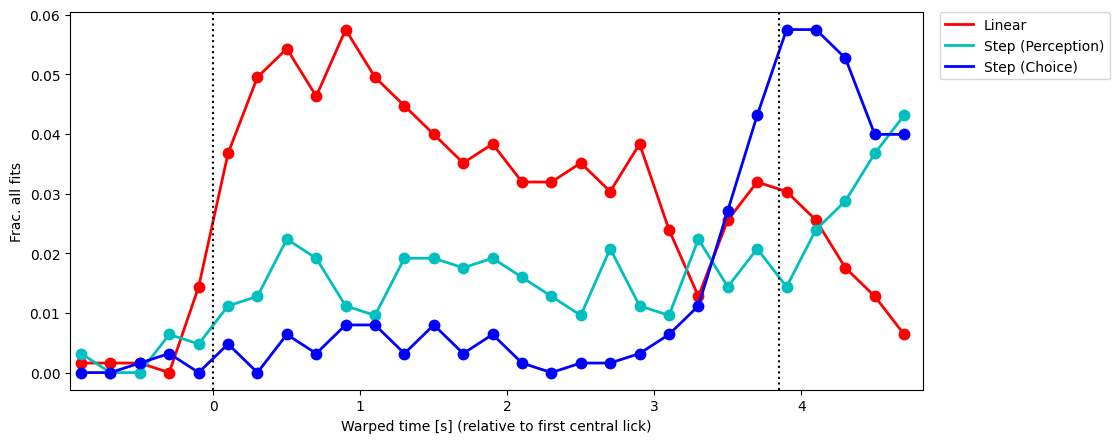

In [36]:
fig, ax = plt.subplots(figsize=(11, 4.9));
den = N_total
n_lin = np.array([sum([label == 'Linear' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_lin / den, '.r', markersize=15);
p1, = ax.plot(t_downsample, n_lin / den, 'r', linewidth=2);
n_perc = np.array([sum([label == 'Step (Perception)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_perc / den, '.c', markersize=15);
p2, = ax.plot(t_downsample, n_perc / den, 'c', linewidth=2);
n_choice = np.array([sum([label == 'Step (Choice)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_choice / den, '.b', markersize=15);
p3, = ax.plot(t_downsample, n_choice / den, 'b', linewidth=2);
ax.set_xlim([t[0], t[-1]]);
ax.set_xlabel('Warped time [s] (relative to first central lick)');
ax.set_ylabel('Frac. all fits');
ax.axvline(0, color='k', linestyle=':');
ax.axvline(IEI_mean_all, color='k', linestyle=':');
ax.legend([p1, p2, p3], ['Linear', 'Step (Perception)', 'Step (Choice)'], 
          bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.);

# Figure 4C
# plt.savefig('plots/experimental/response_profiles_over_time_taller.pdf');

print('Peak fraction of coding units (non-Other):', ((n_lin + n_perc + n_choice) / N_total).max())

In [37]:
# session-by-session
print('Session | n_total | n_linear | n_perception | n_choice | n_other')
print('----------------------------------------------------------------')
count = 0
for sess in included_sessions:
    X, _, _, _, _ = all_data[sess]
    n_neurons_sess = X.shape[1]
    is_linear_sess = np.full(n_neurons_sess, False)
    is_perception_sess = np.full(n_neurons_sess, False)
    is_choice_sess = np.full(n_neurons_sess, False)
    is_other_sess = np.full(n_neurons_sess, False)
    i = 0
    for i_neuron in range(count, count + n_neurons_sess):
        label_seq = [labels_over_time[t][i_neuron] for t in range(len(labels_over_time))]
        is_linear_sess[i] = 'Linear' in label_seq
        is_perception_sess[i] = 'Step (Perception)' in label_seq
        is_choice_sess[i] = 'Step (Choice)' in label_seq
        is_other_sess[i] = (not is_linear_sess[i]) and (not is_perception_sess[i]) and (not is_choice_sess[i])
        i += 1
    print('{:7}   {:7}   {:8}   {:12}   {:8}   {:7}'
          .format(
              sess, 
              n_neurons_sess, 
              is_linear_sess.sum(), 
              is_perception_sess.sum(), 
              is_choice_sess.sum(), 
              is_other_sess.sum()
          )
         )
    count += n_neurons_sess

Session | n_total | n_linear | n_perception | n_choice | n_other
----------------------------------------------------------------
      0        17          4              6          1         8
      1        44         13              9          8        27
      2        21          3             11          1         9
      3        48         22             11          9        23
      4        29          8              5          6        18
      5        68         16             16         10        38
      6        16          3              6          2         9
      7        41          8             12         17        17
      8        17          1              2          4        10
      9        38          6              4         12        22
     10        14          6              4          2         4
     11         7          3              1          1         4
     13        11          4              2          0         5
     14        27        

F = 57.5313
p = 0.0003


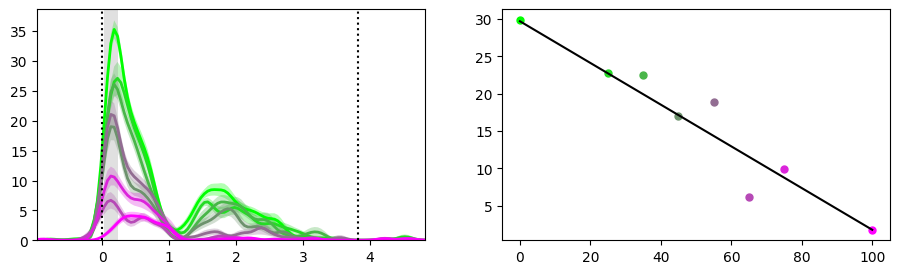

In [38]:
## example linear-coding

ind_neuron = 38
ind_time = 1
smooth_type = 'gaussian'
smooth_width = 11
shade_standard_error = True

inds_neuron = [i for i in range(N_total) if is_linear[i]]
inds_time = [t for t in range(len(labels_over_time)) if labels_over_time[t][inds_neuron[ind_neuron]] == 'Linear']

fig, axes = plt.subplots(1, 2, figsize=(11, 3));
adj_ind_session = []
adj_ind_neuron = []
for i_sess in included_sessions:
    n = all_data[i_sess][0].shape[1]
    adj_ind_session += [i_sess] * n
    adj_ind_neuron += list(range(n))
i_session = adj_ind_session[inds_neuron[ind_neuron]]
i_neuron = adj_ind_neuron[inds_neuron[ind_neuron]]
i_time = inds_time[ind_time]
X, y_conc, _, y_outcome, t = all_data[i_session]
X_smooth = X.copy()
for i in range(X_smooth.shape[0]):
    for j in range(X_smooth.shape[1]):
        X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
window = (t >= t[inds_L[i_time]]) & (t <= t[inds_R[i_time]])
for i_stim, stim in enumerate(unique_stims):
    trial_mask = (y_conc == stim) & (y_outcome == 1)
    if trial_mask.sum() > 0:
        r = X_smooth[trial_mask, i_neuron, :]
        r_mean = r.mean(axis=0)
        r_std = r.std(axis=0) / np.sqrt(trial_mask.sum())
        if shade_standard_error:
            patch = plt.Polygon(
                [(t[i], r_mean[i] - r_std[i]) for i in range(len(t))] + 
                [(t[i], r_mean[i] + r_std[i]) for i in range(len(t))][::-1],
                facecolor=colors[i_stim, :],
                edgecolor=None,
                alpha=0.3
            )
            axes[0].add_patch(patch);
        axes[0].plot(t, r_mean, color=colors[i_stim, :], linewidth=2);
        r_window = r_mean[window].mean()
        axes[1].plot(stim, r_window, '.', color=colors[i_stim, :], markersize=10);
patch = plt.Polygon(
    [(t[inds_L[i_time]], 0), (t[inds_R[i_time]], 0), 
     (t[inds_R[i_time]], axes[0].get_ylim()[1]), (t[inds_L[i_time]], axes[0].get_ylim()[1])],
    facecolor=[0.6, 0.6, 0.6],
    edgecolor=None,
    alpha=0.3
)
axes[0].add_patch(patch);
axes[0].axvline(0, color='k', linestyle=':');
axes[0].axvline(t[-1] - 1, color='k', linestyle=':');
axes[0].set_xlim([t[0], t[-1]]);
axes[0].set_ylim([0, axes[0].get_ylim()[1]]);
x, y = classifications_over_time[i_time][inds_neuron[ind_neuron]]['best_fit_full']
axes[1].plot(x, y, 'k');
F = classifications_over_time[i_time][inds_neuron[ind_neuron]]['F_stat_linear']
p = classifications_over_time[i_time][inds_neuron[ind_neuron]]['p_linear']
print('F = {:.4f}'.format(F))
print('p = {:.4f}'.format(p))

# Figure 4A
# plt.savefig('plots/experimental/psths/linear_coding_session_{}_neuron_{}.pdf'.format(i_session, i_neuron));

F = 27.6270
p = 0.0020


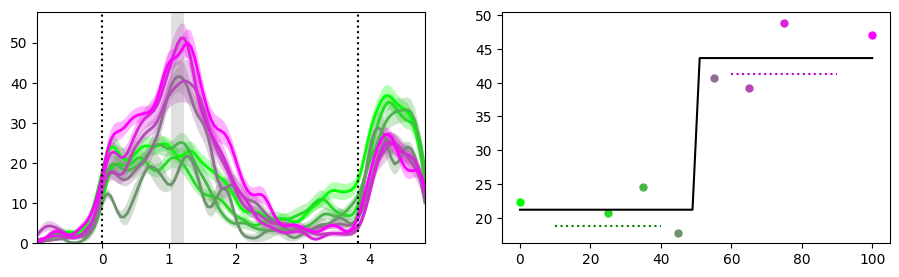

In [39]:
## example perception-coding

ind_neuron = 68
ind_time = 0
smooth_type = 'gaussian'
smooth_width = 11
shade_standard_error = True

inds_neuron = [i for i in range(N_total) if is_perception[i]]
inds_time = [t for t in range(len(labels_over_time)) if labels_over_time[t][inds_neuron[ind_neuron]] == 'Step (Perception)']

fig, axes = plt.subplots(1, 2, figsize=(11, 3));
adj_ind_session = []
adj_ind_neuron = []
for i_sess in included_sessions:
    n = all_data[i_sess][0].shape[1]
    adj_ind_session += [i_sess] * n
    adj_ind_neuron += list(range(n))
i_session = adj_ind_session[inds_neuron[ind_neuron]]
i_neuron = adj_ind_neuron[inds_neuron[ind_neuron]]
i_time = inds_time[ind_time]
X, y_conc, _, y_outcome, t = all_data[i_session]
X_smooth = X.copy()
for i in range(X_smooth.shape[0]):
    for j in range(X_smooth.shape[1]):
        X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
window = (t >= t[inds_L[i_time]]) & (t <= t[inds_R[i_time]])
r_1, r_2 = [], []
for i_stim, stim in enumerate(unique_stims):
    trial_mask = (y_conc == stim) & (y_outcome == 1)
    if trial_mask.sum() > 0:
        r = X_smooth[trial_mask, i_neuron, :]
        r_mean = r.mean(axis=0)
        r_std = r.std(axis=0) / np.sqrt(trial_mask.sum())
        if shade_standard_error:
            patch = plt.Polygon(
                [(t[i], r_mean[i] - r_std[i]) for i in range(len(t))] + 
                [(t[i], r_mean[i] + r_std[i]) for i in range(len(t))][::-1],
                facecolor=colors[i_stim, :],
                edgecolor=None,
                alpha=0.3
            )
            axes[0].add_patch(patch);
        axes[0].plot(t, r_mean, color=colors[i_stim, :], linewidth=2);
        r_window = r_mean[window].mean()
        axes[1].plot(stim, r_window, '.', color=colors[i_stim, :], markersize=10);
    trial_mask = (y_conc == stim) & (y_outcome == 0)
    if trial_mask.sum() > 0:
        temp = X_smooth[trial_mask, i_neuron, :].mean(axis=0)
        if stim < 50:
            r_1.append(temp[window].mean())
        else:
            r_2.append(temp[window].mean())
patch = plt.Polygon(
    [(t[inds_L[i_time]], 0), (t[inds_R[i_time]], 0), 
     (t[inds_R[i_time]], axes[0].get_ylim()[1]), (t[inds_L[i_time]], axes[0].get_ylim()[1])],
    facecolor=[0.6, 0.6, 0.6],
    edgecolor=None,
    alpha=0.3
)
axes[0].add_patch(patch);
axes[0].axvline(0, color='k', linestyle=':');
axes[0].axvline(t[-1] - 1, color='k', linestyle=':');
axes[0].set_xlim([t[0], t[-1]]);
axes[0].set_ylim([0, axes[0].get_ylim()[1]]);
x, y = classifications_over_time[i_time][inds_neuron[ind_neuron]]['best_fit_full']
axes[1].plot(x, y, 'k');
axes[1].plot([10, 40], [np.mean(r_1), np.mean(r_1)], ':g');
axes[1].plot([60, 90], [np.mean(r_2), np.mean(r_2)], ':m');
F = classifications_over_time[i_time][inds_neuron[ind_neuron]]['F_stat_step']
p = classifications_over_time[i_time][inds_neuron[ind_neuron]]['p_step']
print('F = {:.4f}'.format(F))
print('p = {:.4f}'.format(p))

# Figure 4B
# plt.savefig('plots/experimental/psths/perception_coding_session_{}_neuron_{}.pdf'.format(i_session, i_neuron));

F = 29.8462
p = 0.0017


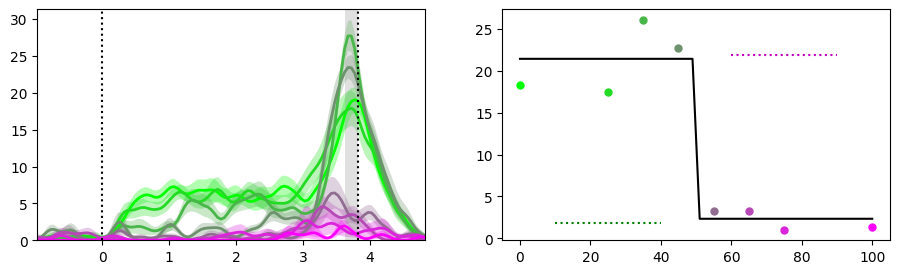

In [40]:
## example choice-coding

ind_neuron = 24
ind_time = 1
smooth_type = 'gaussian'
smooth_width = 11
shade_standard_error = True

inds_neuron = [i for i in range(N_total) if is_choice[i]]
inds_time = [t for t in range(len(labels_over_time)) if labels_over_time[t][inds_neuron[ind_neuron]] == 'Step (Choice)']

fig, axes = plt.subplots(1, 2, figsize=(11, 3));
adj_ind_session = []
adj_ind_neuron = []
for i_sess in included_sessions:
    n = all_data[i_sess][0].shape[1]
    adj_ind_session += [i_sess] * n
    adj_ind_neuron += list(range(n))
i_session = adj_ind_session[inds_neuron[ind_neuron]]
i_neuron = adj_ind_neuron[inds_neuron[ind_neuron]]
i_time = inds_time[ind_time]
X, y_conc, _, y_outcome, t = all_data[i_session]
X_smooth = X.copy()
for i in range(X_smooth.shape[0]):
    for j in range(X_smooth.shape[1]):
        X_smooth[i, j, :] = smooth(X_smooth[i, j, :], smooth_type, smooth_width)
window = (t >= t[inds_L[i_time]]) & (t <= t[inds_R[i_time]])
r_1, r_2 = [], []
for i_stim, stim in enumerate(unique_stims):
    trial_mask = (y_conc == stim) & (y_outcome == 1)
    if trial_mask.sum() > 0:
        r = X_smooth[trial_mask, i_neuron, :]
        r_mean = r.mean(axis=0)
        r_std = r.std(axis=0) / np.sqrt(trial_mask.sum())
        if shade_standard_error:
            patch = plt.Polygon(
                [(t[i], r_mean[i] - r_std[i]) for i in range(len(t))] + 
                [(t[i], r_mean[i] + r_std[i]) for i in range(len(t))][::-1],
                facecolor=colors[i_stim, :],
                edgecolor=None,
                alpha=0.3
            )
            axes[0].add_patch(patch);
        axes[0].plot(t, r_mean, color=colors[i_stim, :], linewidth=2);
        r_window = r_mean[window].mean()
        axes[1].plot(stim, r_window, '.', color=colors[i_stim, :], markersize=10);
    trial_mask = (y_conc == stim) & (y_outcome == 0)
    if trial_mask.sum() > 0:
        temp = X_smooth[trial_mask, i_neuron, :].mean(axis=0)
        if stim < 50:
            r_1.append(temp[window].mean())
        else:
            r_2.append(temp[window].mean())
patch = plt.Polygon(
    [(t[inds_L[i_time]], 0), (t[inds_R[i_time]], 0), 
     (t[inds_R[i_time]], axes[0].get_ylim()[1]), (t[inds_L[i_time]], axes[0].get_ylim()[1])],
    facecolor=[0.6, 0.6, 0.6],
    edgecolor=None,
    alpha=0.3
)
axes[0].add_patch(patch);
axes[0].axvline(0, color='k', linestyle=':');
axes[0].axvline(t[-1] - 1, color='k', linestyle=':');
axes[0].set_xlim([t[0], t[-1]]);
axes[0].set_ylim([0, axes[0].get_ylim()[1]]);
x, y = classifications_over_time[i_time][inds_neuron[ind_neuron]]['best_fit_full']
axes[1].plot(x, y, 'k');
axes[1].plot([10, 40], [np.mean(r_1), np.mean(r_1)], ':g');
axes[1].plot([60, 90], [np.mean(r_2), np.mean(r_2)], ':m');
F = classifications_over_time[i_time][inds_neuron[ind_neuron]]['F_stat_step']
p = classifications_over_time[i_time][inds_neuron[ind_neuron]]['p_step']
print('F = {:.4f}'.format(F))
print('p = {:.4f}'.format(p))

# Figure 4C
# plt.savefig('plots/experimental/psths/choice_coding_session_{}_neuron_{}.pdf'.format(i_session, i_neuron));